# **Capstone - Machine Learning Based Intrusion Detection System**

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import plotly as px

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
!git clone https://github.com/anthonyfeaster/UCB-AIML.git
%cd /content/UCB-AIML/Capstone
!ls
!ls data

In [7]:
#Creating a dataframe from the csv
df = pd.read_csv('data/network_traffic_data.csv')

In [8]:
df.head()

,Duration,Protocol,SourceIP,DestinationIP,SourcePort,DestinationPort,PacketCount,ByteCount,Label
0,24.077749,TCP,192.168.1.239,192.168.1.234,8055,1,827,198244,Attack
1,97.252384,ICMP,192.168.1.176,192.168.1.82,63174,687,673,1202973,Normal
2,85.842654,TCP,192.168.1.120,192.168.1.113,30873,570,319,984671,Attack
3,79.196991,UDP,192.168.1.212,192.168.1.140,4410,683,375,36284,Normal
4,34.928018,TCP,192.168.1.17,192.168.1.223,4702,989,465,817463,Normal


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Duration         2000 non-null   float64
 1   Protocol         2000 non-null   object 
 2   SourceIP         2000 non-null   object 
 3   DestinationIP    2000 non-null   object 
 4   SourcePort       2000 non-null   int64  
 5   DestinationPort  2000 non-null   int64  
 6   PacketCount      2000 non-null   int64  
 7   ByteCount        2000 non-null   int64  
 8   Label            2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB


In [10]:
#Printing Number of Rows and Columns plus Column Names
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(f"Column Names: {df.columns.tolist()}")

Rows: 2000, Columns: 9
Column Names: ['Duration', 'Protocol', 'SourceIP', 'DestinationIP', 'SourcePort', 'DestinationPort', 'PacketCount', 'ByteCount', 'Label']


In [14]:
df.describe(include='object')

,Protocol,SourceIP,DestinationIP,Label
count,2000,2000,2000,2000
unique,3,255,255,2
top,TCP,192.168.1.177,192.168.1.226,Attack
freq,690,16,17,1022


In [58]:
#Renaming the traffic classification to industry standard terms
df['Label'] = df['Label'].replace({
    'Normal': 'Benign',
    'Attack': 'Malicious'
})

In [66]:
df['Label'].value_counts()



,count
Label,
Malicious,1022
Benign,978


In [67]:

(df['Label'].value_counts() * 100 / len(df)).map("{:.2f}%".format).sort_values(ascending=False)

traffic_summary = df['Label'].value_counts().reset_index()
traffic_summary.columns = ['Traffic', 'Count']
traffic_summary['Percentage'] = (traffic_summary['Count'] / traffic_summary['Count'].sum() * 100).map("{:.2f}%".format)

traffic_summary

,Traffic,Count,Percentage
0,Malicious,1022,51.10%
1,Benign,978,48.90%


In [61]:
df['Protocol'].value_counts()

,count
Protocol,
TCP,690
ICMP,658
UDP,652


In [56]:
protocol_summary = df['Protocol'].value_counts().reset_index()
protocol_summary.columns = ['Protocol', 'Count']
protocol_summary['Percentage'] = (protocol_summary['Count'] / protocol_summary['Count'].sum() * 100).map("{:.2f}%".format)

protocol_summary

,Protocol,Count,Percentage
0,TCP,690,34.50%
1,ICMP,658,32.90%
2,UDP,652,32.60%


In [27]:
#Looking for Null values
df.isnull().sum()

,0
Duration,0
Protocol,0
SourceIP,0
DestinationIP,0
SourcePort,0
DestinationPort,0
PacketCount,0
ByteCount,0
Label,0


/tmp/ipykernel_1759/1927732476.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df, palette='Set1')
/tmp/ipykernel_1759/1927732476.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


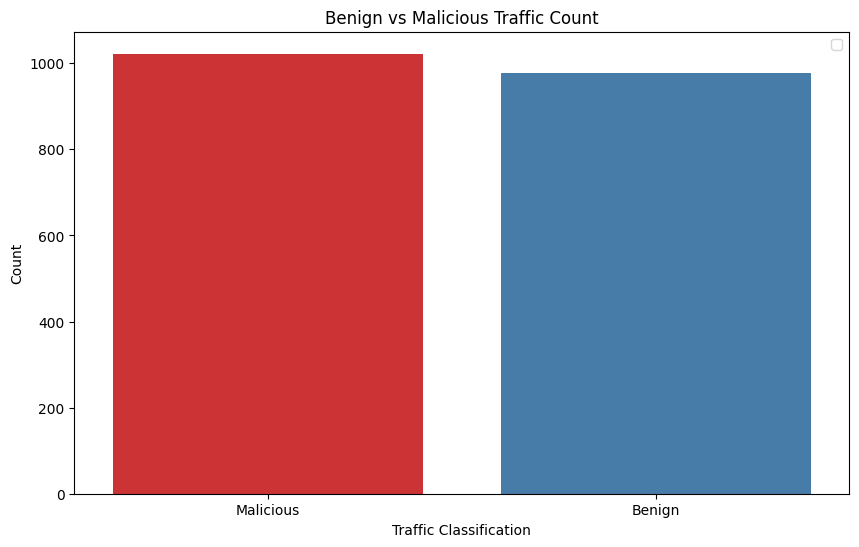

In [74]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Label', data=df, palette='Set1')
plt.title('Benign vs Malicious Traffic Count')
plt.xlabel('Traffic Classification')
plt.ylabel('Count')
plt.show()